# ADS-B Analytics - Exploratory Data Analysis

Live aircraft data collected around **Detroit Metro Airport (KDTW)** via the OpenSky Network API,
stored in PostgreSQL/PostGIS. This notebook explores patterns in the dataset:
traffic by time of day, altitude distributions, aircraft frequency, and individual flight paths.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import os
from dotenv import load_dotenv

load_dotenv("../.env")

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

def get_db_connection():
    return psycopg2.connect(
        dbname=os.getenv("DB_NAME", "adsb"),
        user=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD", ""),
        host=os.getenv("DB_HOST", "localhost"),
        port=os.getenv("DB_PORT", "5432")
    )

query = """
    SELECT *
    FROM aircraft_states
    WHERE latitude IS NOT NULL AND longitude IS NOT NULL;
"""

conn = get_db_connection()
df = pd.read_sql(query, conn)
conn.close()

print(f"Loaded {len(df):,} records")
df.head()

Matplotlib is building the font cache; this may take a moment.


Loaded 11,606 records


/var/folders/m9/jlvnlqsn5xd_z756_5wrmjf40000gn/T/ipykernel_5464/4058347246.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,squawk,position,collected_at
0,1,a7133f,DAL492,United States,1781046491,1781046491,-83.3087,42.3049,739.14,False,86.91,210.21,-3.58,716.28,1006,0101000020E61000009D11A5BDC1D354C0744694F60627...,2026-06-09 19:08:13.921942
1,2,a9fe88,JRE743,United States,1781046491,1781046491,-83.4299,42.0083,2438.40,False,130.64,193.43,15.93,2499.36,4445,0101000020E61000003A234A7B83DB54C0454772F90F01...,2026-06-09 19:08:13.921942
2,3,a988f0,DAL1856,United States,1781046491,1781046491,-83.6645,42.1583,3291.84,False,169.88,70.36,-4.55,3406.14,6043,0101000020E61000004A0C022B87EA54C0787AA52C4314...,2026-06-09 19:08:13.921942
3,4,a77dae,DAL2244,United States,1781046491,1781046491,-83.3439,42.2567,419.10,False,70.66,208.24,-3.25,381.00,1424,0101000020E61000000B46257502D654C00D71AC8BDB20...,2026-06-09 19:08:13.921942
4,5,a8496e,FFT1958,United States,1781046491,1781046491,-83.1447,41.8819,4587.24,False,126.73,304.92,0.33,4792.98,2071,0101000020E6100000CCEEC9C342C954C0D42B6519E2F0...,2026-06-09 19:08:13.921942


## Dataset Overview

A quick look at the scope of the data: time range, unique aircraft, and countries represented.

In [2]:
df["collected_at"] = pd.to_datetime(df["collected_at"])

print(f"Total records:     {len(df):,}")
print(f"Unique aircraft:   {df['icao24'].nunique():,}")
print(f"Countries:         {df['origin_country'].nunique()}")
print(f"Date range:        {df['collected_at'].min()}  →  {df['collected_at'].max()}")
print(f"Airborne records:  {(~df['on_ground']).sum():,} ({(~df['on_ground']).mean()*100:.1f}%)")

Total records:     11,606
Unique aircraft:   1,262
Countries:         19
Date range:        2026-06-09 19:08:13.921942  →  2026-06-15 12:12:15.252132
Airborne records:  11,384 (98.1%)


## Traffic Patterns by Hour of Day

Unique aircraft tracked during each hour of the day, aggregated across all days collected so far.

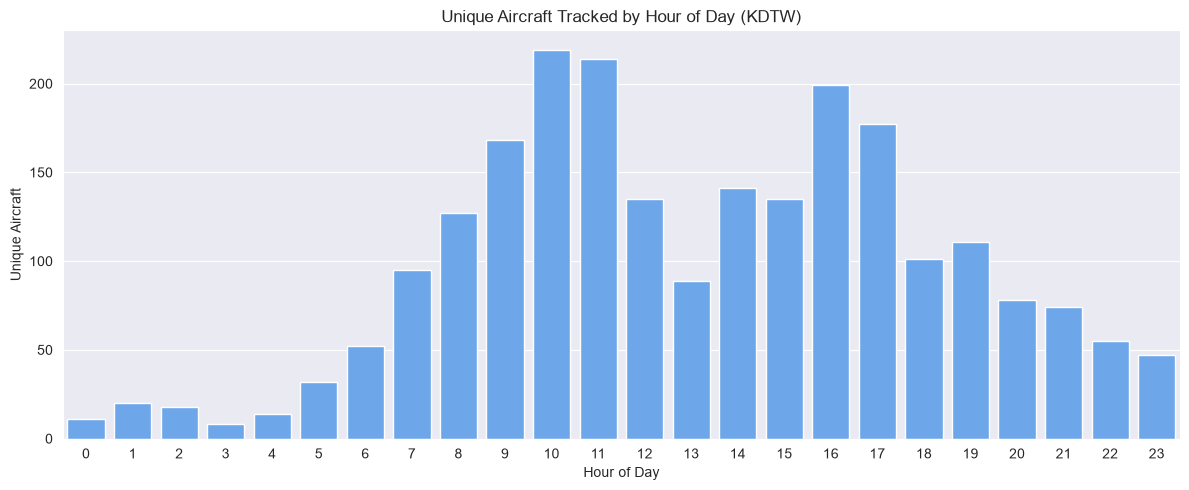

In [3]:
df["hour"] = df["collected_at"].dt.hour

hourly = df.groupby("hour")["icao24"].nunique().reset_index()
hourly.columns = ["hour", "unique_aircraft"]

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly, x="hour", y="unique_aircraft", color="#58a6ff")
plt.title("Unique Aircraft Tracked by Hour of Day (KDTW)")
plt.xlabel("Hour of Day")
plt.ylabel("Unique Aircraft")
plt.tight_layout()
plt.show()

## Altitude Distribution

Distribution of barometric altitude for airborne aircraft. Values above ~13,000m are
excluded as they represent sensor/data glitches rather than real readings —
no aircraft in this dataset realistically flies above that altitude.

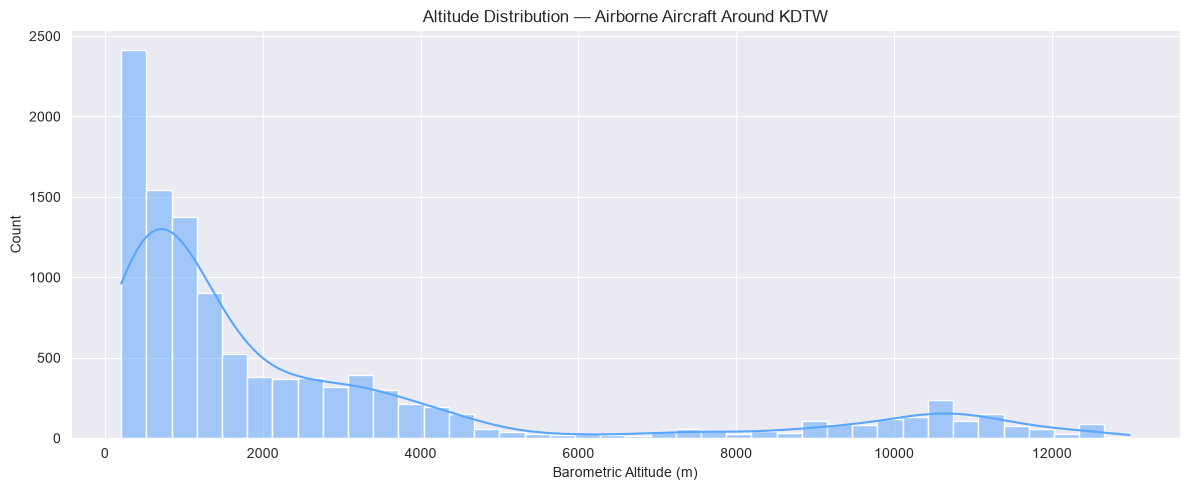

In [4]:
airborne = df[(~df["on_ground"]) & (df["baro_altitude"].notna()) & (df["baro_altitude"] < 13000)]

plt.figure(figsize=(12, 5))
sns.histplot(airborne["baro_altitude"], bins=40, color="#58a6ff", kde=True)
plt.title("Altitude Distribution — Airborne Aircraft Around KDTW")
plt.xlabel("Barometric Altitude (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Most Frequent Aircraft

Aircraft appearing most often in the dataset — likely a mix of frequent commercial
routes and aircraft doing repeated circuits (training/pattern work) around KDTW.

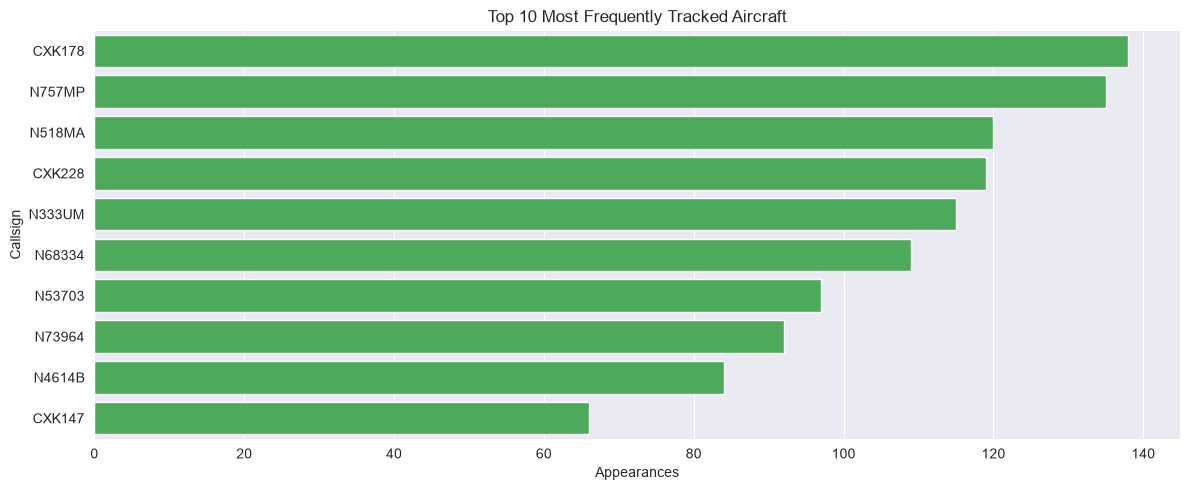

In [5]:
top_aircraft = (
    df[df["callsign"].notna()]
    .groupby("callsign")["id"]
    .count()
    .reset_index()
    .rename(columns={"id": "appearances"})
    .sort_values("appearances", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_aircraft, x="appearances", y="callsign", color="#3fb950")
plt.title("Top 10 Most Frequently Tracked Aircraft")
plt.xlabel("Appearances")
plt.ylabel("Callsign")
plt.tight_layout()
plt.show()

## Flight Path of a Single Aircraft

A close look at `CXK178` — the most frequently tracked aircraft in the dataset.
The shape of its path reveals whether it's flying point-to-point or doing repeated circuits
(common for flight training aircraft).

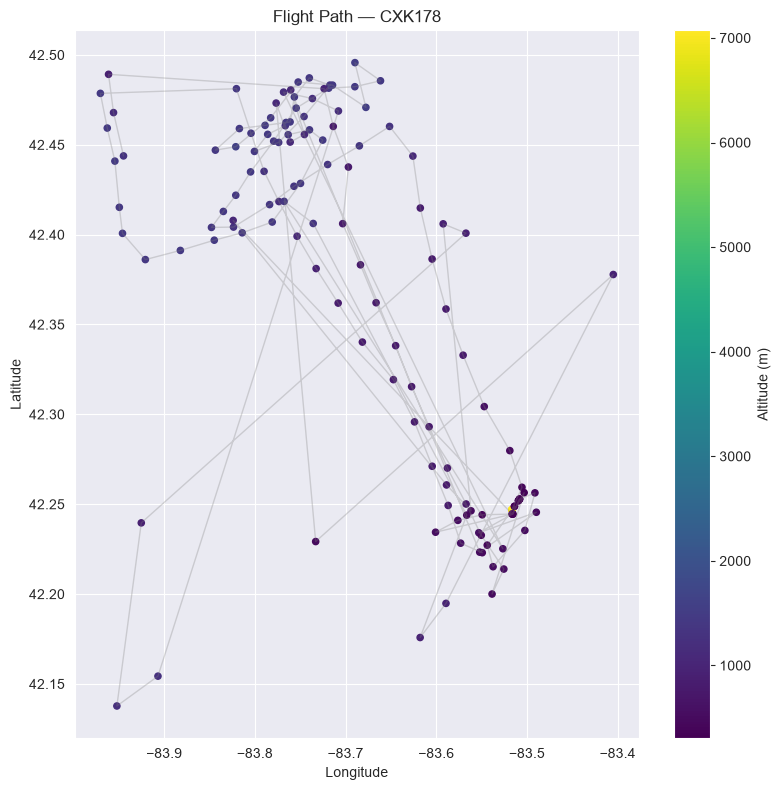

In [6]:
sample = df[df["callsign"].str.strip() == "CXK178"].sort_values("collected_at")

plt.figure(figsize=(8, 8))
sc = plt.scatter(sample["longitude"], sample["latitude"],
                  c=sample["baro_altitude"], cmap="viridis", s=20)
plt.plot(sample["longitude"], sample["latitude"], color="gray", alpha=0.3, linewidth=1)
plt.colorbar(sc, label="Altitude (m)")
plt.title("Flight Path — CXK178")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

### A Closer Look: Is CXK178 One Aircraft or Many?

The path above doesn't look like a single repeated circuit — it spans a huge area
with several disconnected clusters. Let's check whether multiple aircraft (different
`icao24` codes) share this callsign, and whether the pattern separates cleanly by day.

Unique icao24 codes for CXK178: 1
icao24
a25e15    138
Name: count, dtype: int64


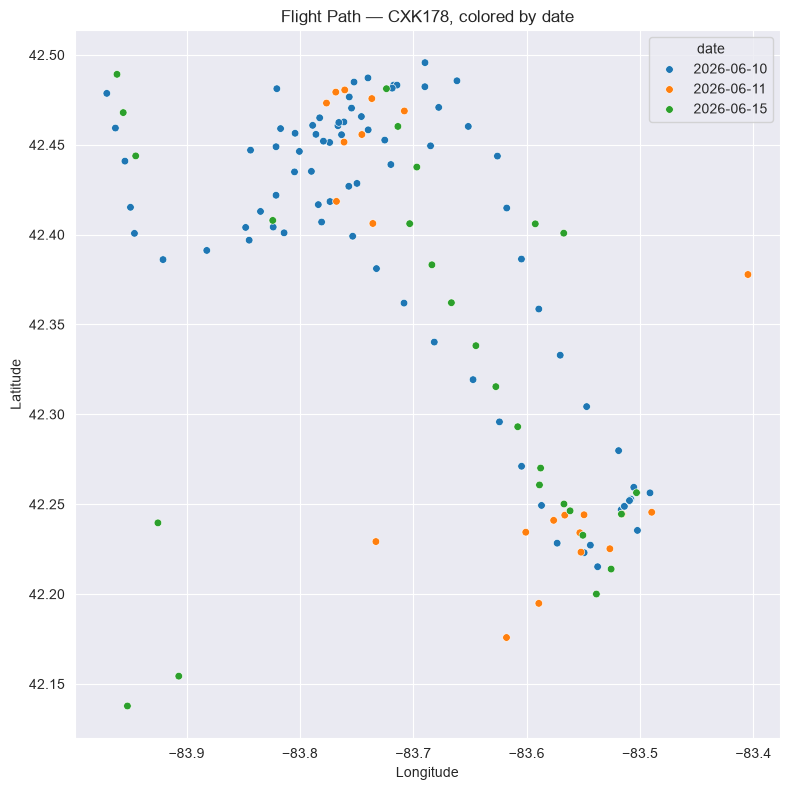

In [7]:
print("Unique icao24 codes for CXK178:", sample["icao24"].nunique())
print(sample["icao24"].value_counts())

sample["date"] = sample["collected_at"].dt.date

plt.figure(figsize=(8, 8))
sns.scatterplot(data=sample, x="longitude", y="latitude", hue="date", palette="tab10", s=30)
plt.title("Flight Path — CXK178, colored by date")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

**Finding:** CXK178 corresponds to a single aircraft (`icao24 = a25e15`) appearing 138 times
across multiple days, with positions spread across a ~40km area at predominantly low altitude
(mostly under 2,000m). The "CXK" callsign prefix corresponds to **Cargojet Airways**, a Canadian
cargo carrier — this looks like a single cargo aircraft making frequent short hops between
regional airports in southeast Michigan, rather than a training aircraft doing a repeated circuit.
This is a good reminder that "appears frequently" doesn't automatically mean "doing pattern work" —
it's worth checking the actual geography before assuming.

## Key Findings

- **Daily traffic pattern**: KDTW shows a clear two-peak pattern — a morning bank around
  10-11am and an afternoon bank around 4-5pm, with a midday dip and quiet overnight hours.
- **Altitude is bimodal**: most tracked positions are at low altitude (0-2,000m, approach/
  departure/local traffic), with a secondary cluster around 10,000-11,000m (cruising/transit
  traffic passing through the wider airspace).
- **"Frequent" ≠ "circling"**: the most-tracked aircraft (CXK178, a Cargojet cargo plane)
  isn't doing pattern work — it's a single aircraft making many short regional hops over
  multiple days, covering a wide geographic area at low altitude.
- **Data quality matters**: raw altitude readings include sensor glitches up to ~37,000m
  that must be filtered before any analysis — a recurring theme across this whole project.

## Next Steps

- Retrain the ML models (anomaly detection, congestion prediction, clustering) on this
  larger ~11,600-record dataset and compare results to the earlier ~9,400-record run
- Investigate other high-frequency callsigns the same way to build a taxonomy of traffic types
- Add weather data as a feature for congestion prediction